In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.colors as mcolors

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
idir    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/final/'
ds_traj = xr.open_dataset(idir+'dataset_traj.nc')
ds_temp = xr.open_dataset(idir+'dataset_temp.nc')
ds_wave = xr.open_dataset(idir+'dataset_wave.nc')

In [3]:
ds = ds_temp

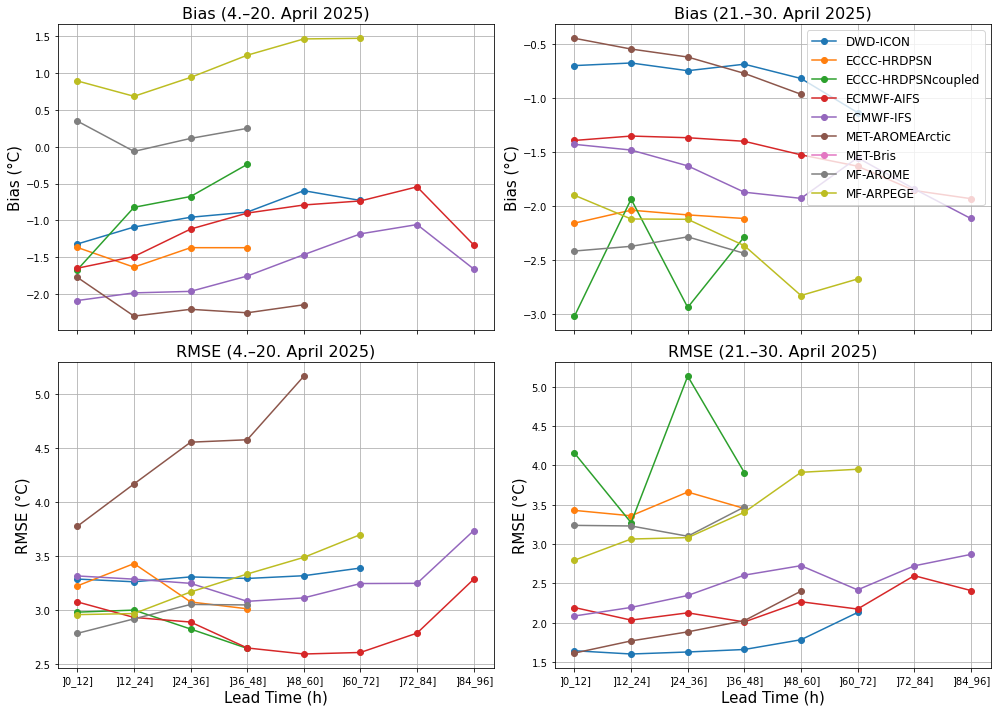

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Setup
models = ds['model'].values
lt_values = ds['lt_int'].values
n_models = len(models)
n_lt = len(lt_values)
n_buoys = ds['temp_1m_calibrated'].shape[0]

# Time windows
time_windows = [
    (np.datetime64("2024-04-04"), np.datetime64("2024-04-20")),
    (np.datetime64("2024-04-21"), np.datetime64("2024-04-30"))
]

bias_all = np.full((2, n_models, n_lt), np.nan)
rmse_all = np.full((2, n_models, n_lt), np.nan)

for t, (start_date, end_date) in enumerate(time_windows):
    time_mask = (ds['time_ds'] >= start_date) & (ds['time_ds'] <= end_date)
    time_indices = np.where(time_mask)[0]

    for m in [0, 1, 2, 3, 4, 5, 7, 8]: # Exclude Bris
        for lt in range(n_lt):
            diffs = []

            for tr in range(n_buoys):
                obs = ds['temp_1m_calibrated'].isel(tr_nr=tr, time_ds=time_indices) - 273.15
                mod = ds['T2M'].isel(model=m, lt_int=lt, tr_nr=tr, time_ds=time_indices) - 273.15

                flag = (ds['temp_flag_1m'].isel(tr_nr=tr, time_ds=time_indices) == 1) | \
                       (ds['temp_flag_cons'].isel(tr_nr=tr, time_ds=time_indices) == 1) | \
                       (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=tr, time_ds=time_indices) > 300)

                valid = ~flag

                obs_valid = obs.where(valid)
                mod_valid = mod.where(valid)

                diff = mod_valid - obs_valid
                diffs.append(diff)

            diffs = xr.concat(diffs, dim='time_ds').values
            diffs = diffs[~np.isnan(diffs)]

            if diffs.size > 0:
                bias_all[t, m, lt] = np.mean(diffs)
                rmse_all[t, m, lt] = np.sqrt(np.mean(diffs**2))

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
time_labels = ["4.–20. April 2025", "21.–30. April 2025"]

# Bias plots
for t in range(2):
    ax = axs[0, t]
    for m, name in enumerate(models):
        ax.plot(lt_values, bias_all[t, m], marker='o', label=name)
    ax.set_title(f"Bias ({time_labels[t]})", fontsize=16)
    ax.set_ylabel("Bias (°C)", fontsize=15)
    ax.grid(True)
    if t==1:
        ax.legend(fontsize=12)
   

# RMSE plots
for t in range(2):
    ax = axs[1, t]
    for m, name in enumerate(models):
        ax.plot(lt_values, rmse_all[t, m], marker='o', label=name)
    ax.set_title(f"RMSE ({time_labels[t]})", fontsize=16)
    ax.set_xlabel("Lead Time (h)", fontsize=15)
    ax.set_ylabel("RMSE (°C)", fontsize=15)
    ax.grid(True)
   

plt.tight_layout()
plt.savefig("BiasRMSE_Temp2024.png", dpi=300)  # Save the figure
plt.show()


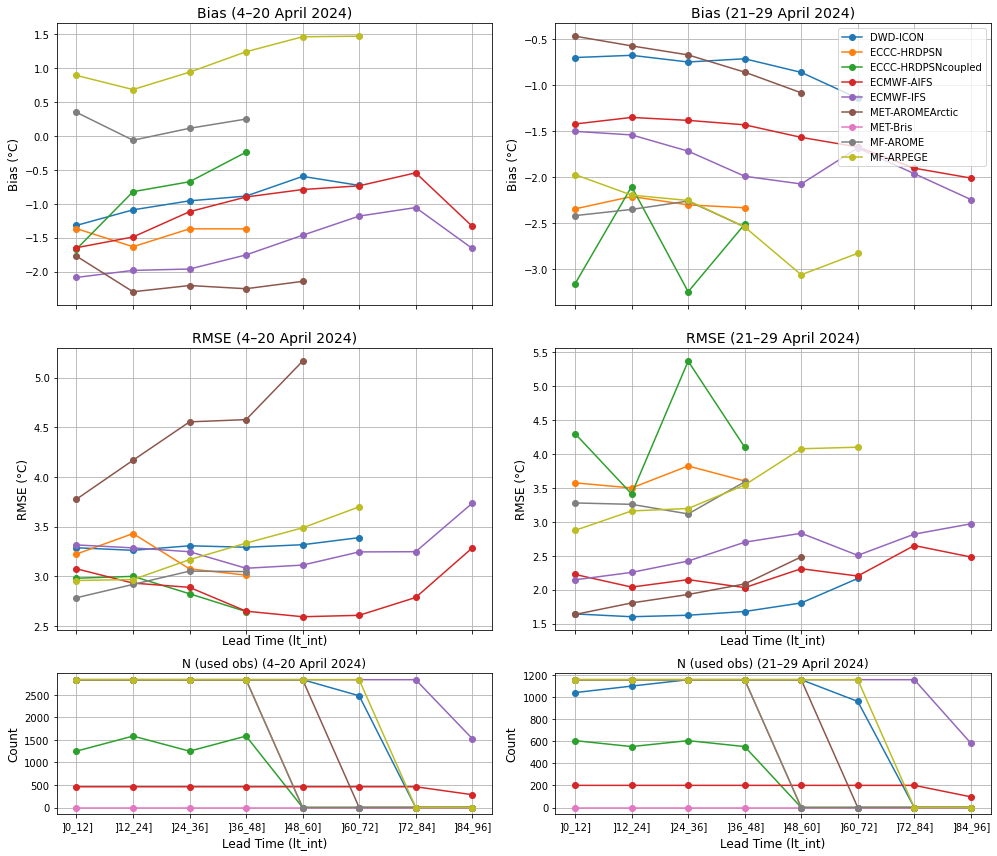

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Setup
models = ds['model'].values
lt_values = ds['lt_int'].values
n_models = len(models)
n_lt = len(lt_values)
n_buoys = ds['temp_1m_calibrated'].shape[0]

# Time windows
time_windows = [
    (np.datetime64("2024-04-04"), np.datetime64("2024-04-20")),
    (np.datetime64("2024-04-21"), np.datetime64("2024-04-29"))
]

time_labels = ["4–20 April 2024", "21–29 April 2024"]

bias_all = np.full((2, n_models, n_lt), np.nan)
rmse_all = np.full((2, n_models, n_lt), np.nan)
counts_all = np.zeros((2, n_models, n_lt), dtype=int)

for t, (start_date, end_date) in enumerate(time_windows):
    time_mask = (ds['time_ds'] >= start_date) & (ds['time_ds'] <= end_date)
    time_indices = np.where(time_mask)[0]

    for m in [0, 1, 2, 3, 4, 5, 7, 8]: # exclude Bris
        for lt in range(n_lt):
            diffs = []

            for tr in range(n_buoys):
                obs = ds['temp_1m_calibrated'].isel(tr_nr=tr, time_ds=time_indices) - 273.15
                mod = ds['T2M'].isel(model=m, lt_int=lt, tr_nr=tr, time_ds=time_indices) - 273.15

                flag = (ds['temp_flag_1m'].isel(tr_nr=tr, time_ds=time_indices) == 1) | \
                       (ds['temp_flag_cons'].isel(tr_nr=tr, time_ds=time_indices) == 1) | \
                       (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=tr, time_ds=time_indices) > 300)

                valid = ~flag

                obs_valid = obs.where(valid)
                mod_valid = mod.where(valid)

                diff = mod_valid - obs_valid
                diffs.append(diff)

            diffs = xr.concat(diffs, dim='time_ds').values
            diffs = diffs[~np.isnan(diffs)]

            counts_all[t, m, lt] = diffs.size

            if diffs.size > 0:
                bias_all[t, m, lt] = np.mean(diffs)
                rmse_all[t, m, lt] = np.sqrt(np.mean(diffs**2))

# Plotting
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})

# Bias plots
for t in range(2):
    ax = axs[0, t]
    for m, name in enumerate(models):
        ax.plot(lt_values, bias_all[t, m], marker='o', label=name)
    ax.set_title(f"Bias ({time_labels[t]})", fontsize=14)
    ax.set_ylabel("Bias (°C)", fontsize=12)
    ax.grid(True)
    if t==1:
        ax.legend(fontsize=10)

# RMSE plots
for t in range(2):
    ax = axs[1, t]
    for m, name in enumerate(models):
        ax.plot(lt_values, rmse_all[t, m], marker='o', label=name)
    ax.set_title(f"RMSE ({time_labels[t]})", fontsize=14)
    ax.set_xlabel("Lead Time (lt_int)", fontsize=12)
    ax.set_ylabel("RMSE (°C)", fontsize=12)
    ax.grid(True)
   

# Observation count plots
for t in range(2):
    ax = axs[2, t]
    for m, name in enumerate(models):
        ax.plot(lt_values, counts_all[t, m], marker='o', label=name)
    ax.set_title(f"N (used obs) ({time_labels[t]})", fontsize=12)
    ax.set_xlabel("Lead Time (lt_int)", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.grid(True)
   

plt.tight_layout()
plt.show()